# User Profiling and Segmnetation

<img src='https://5.imimg.com/data5/TI/TT/DB/SELLER-4776810/7.jpg'>

The aim of this study is to analyze user data and group users with similar behaviors and characteristics using clustering techniques, in order to better understand the user base.

In [129]:
import pandas as pd
import warnings 
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
import numpy as np

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from yellowbrick.cluster import KElbowVisualizer
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv('user_profiles_for_ads.csv')

In [3]:
df.head()

,User ID,Age,Gender,Location,Language,Education Level,Likes and Reactions,Followed Accounts,Device Usage,Time Spent Online (hrs/weekday),Time Spent Online (hrs/weekend),Click-Through Rates (CTR),Conversion Rates,Ad Interaction Time (sec),Income Level,Top Interests
0,1,25-34,Female,Suburban,Hindi,Technical,5640,190,Mobile Only,4.5,1.7,0.193,0.067,25,20k-40k,Digital Marketing
1,2,65+,Male,Urban,Hindi,PhD,9501,375,Tablet,0.5,7.7,0.114,0.044,68,0-20k,Data Science
2,3,45-54,Female,Suburban,Spanish,Technical,4775,187,Mobile Only,4.5,5.6,0.153,0.095,80,60k-80k,Fitness and Wellness
3,4,35-44,Female,Rural,Spanish,PhD,9182,152,Desktop Only,3.1,4.2,0.093,0.061,65,100k+,"Gaming, DIY Crafts"
4,5,25-34,Female,Urban,English,Technical,6848,371,Mobile Only,2.0,3.8,0.175,0.022,99,20k-40k,"Fitness and Wellness, Investing and Finance, G..."


In [6]:
df.head(20)

,User ID,Age,Gender,Location,Language,Education Level,Likes and Reactions,Followed Accounts,Device Usage,Time Spent Online (hrs/weekday),Time Spent Online (hrs/weekend),Click-Through Rates (CTR),Conversion Rates,Ad Interaction Time (sec),Income Level,Top Interests
0,1,25-34,Female,Suburban,Hindi,Technical,5640,190,Mobile Only,4.5,1.7,0.193,0.067,25,20k-40k,Digital Marketing
1,2,65+,Male,Urban,Hindi,PhD,9501,375,Tablet,0.5,7.7,0.114,0.044,68,0-20k,Data Science
2,3,45-54,Female,Suburban,Spanish,Technical,4775,187,Mobile Only,4.5,5.6,0.153,0.095,80,60k-80k,Fitness and Wellness
3,4,35-44,Female,Rural,Spanish,PhD,9182,152,Desktop Only,3.1,4.2,0.093,0.061,65,100k+,"Gaming, DIY Crafts"
4,5,25-34,Female,Urban,English,Technical,6848,371,Mobile Only,2.0,3.8,0.175,0.022,99,20k-40k,"Fitness and Wellness, Investing and Finance, G..."
5,6,25-34,Female,Suburban,Hindi,Master,6203,257,Mobile + Desktop,3.8,3.3,0.209,0.048,44,100k+,"Gourmet Cooking, Software Engineering, Eco-Fri..."
6,7,18-24,Female,Suburban,Hindi,Bachelor,1573,136,Mobile + Desktop,2.8,7.9,0.172,0.068,8,100k+,"Gardening, Digital Marketing, Music Production"
7,8,55-64,Male,Suburban,Hindi,PhD,3343,272,Desktop Only,2.7,1.9,0.128,0.032,35,40k-60k,"Music Production, Photography, Gaming, Travel ..."
8,9,45-54,Female,Urban,Spanish,High School,2281,49,Mobile + Desktop,1.0,3.2,0.115,0.008,159,20k-40k,"Eco-Friendly Living, Gardening"
9,10,45-54,Male,Rural,Hindi,Bachelor,9741,421,Mobile + Desktop,2.3,4.4,0.161,0.058,157,100k+,"Digital Marketing, Travel and Adventure"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   User ID                          1000 non-null   int64  
 1   Age                              1000 non-null   object 
 2   Gender                           1000 non-null   object 
 3   Location                         1000 non-null   object 
 4   Language                         1000 non-null   object 
 5   Education Level                  1000 non-null   object 
 6   Likes and Reactions              1000 non-null   int64  
 7   Followed Accounts                1000 non-null   int64  
 8   Device Usage                     1000 non-null   object 
 9   Time Spent Online (hrs/weekday)  1000 non-null   float64
 10  Time Spent Online (hrs/weekend)  1000 non-null   float64
 11  Click-Through Rates (CTR)        1000 non-null   float64
 12  Conversion Rates     

In [5]:
df.isnull().sum()

User ID                            0
Age                                0
Gender                             0
Location                           0
Language                           0
Education Level                    0
Likes and Reactions                0
Followed Accounts                  0
Device Usage                       0
Time Spent Online (hrs/weekday)    0
Time Spent Online (hrs/weekend)    0
Click-Through Rates (CTR)          0
Conversion Rates                   0
Ad Interaction Time (sec)          0
Income Level                       0
Top Interests                      0
dtype: int64

In [29]:
df.describe()

,User ID,Likes and Reactions,Followed Accounts,Time Spent Online (hrs/weekday),Time Spent Online (hrs/weekend),Click-Through Rates (CTR),Conversion Rates,Ad Interaction Time (sec)
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,4997.084000,251.438000,2.757500,4.601600,0.125333,0.049805,91.425000
std,288.819436,2838.494365,141.941557,1.279735,2.026234,0.071187,0.028670,51.497965
min,1.000000,101.000000,10.000000,0.500000,1.000000,0.000000,0.000000,5.000000
25%,250.750000,2661.250000,126.000000,1.700000,2.900000,0.065000,0.026000,45.750000
50%,500.500000,5002.500000,245.500000,2.800000,4.700000,0.128000,0.049000,90.000000
75%,750.250000,7348.750000,377.000000,3.800000,6.400000,0.186000,0.073000,137.250000
max,1000.000000,9973.000000,498.000000,5.000000,8.000000,0.250000,0.100000,179.000000


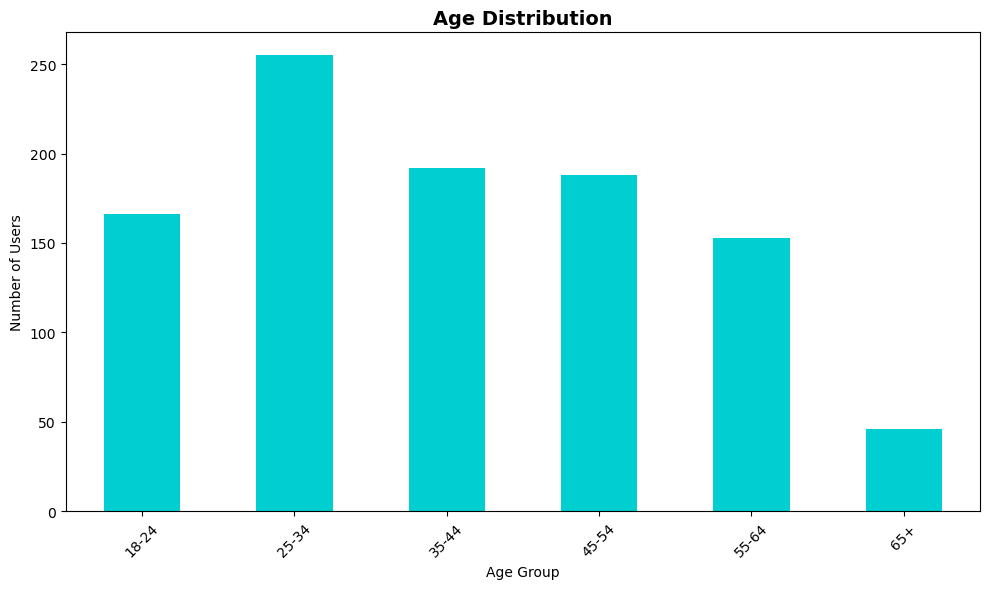

In [9]:
# Age Distribution
plt.figure(figsize=(10, 6))
df['Age'].value_counts().sort_index().plot(kind='bar', color='#00CED1')
plt.title('Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

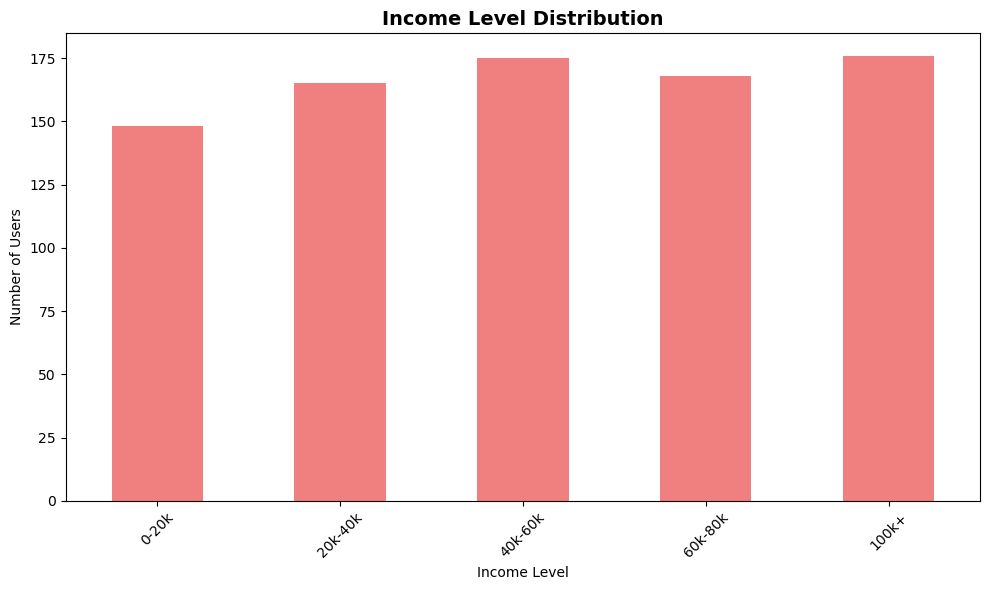

In [16]:
# Income Level Distribution
plt.figure(figsize=(10, 6))
income_order = ['0-20k', '20k-40k', '40k-60k', '60k-80k', '100k+']
df['Income Level'].value_counts().reindex(income_order).plot(kind='bar', color='#F08080')
plt.title('Income Level Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Income Level')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

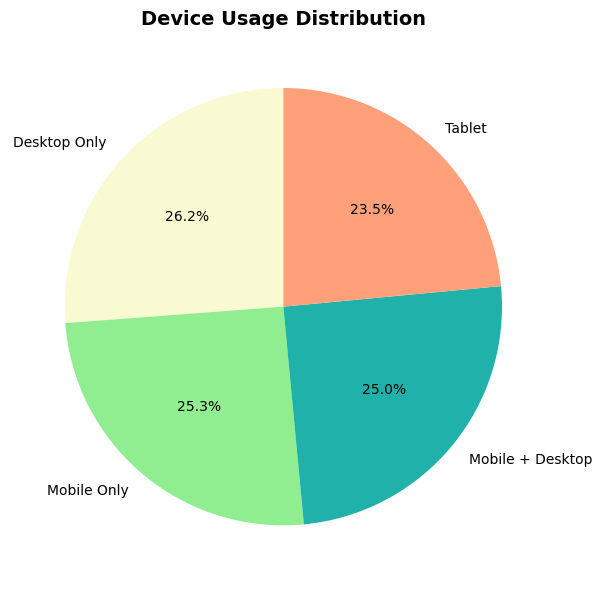

In [15]:
# Device Usage
plt.figure(figsize=(8, 6))
device_counts = df['Device Usage'].value_counts()
colors = ['#FAFAD2', '#90EE90', '#20B2AA', '#FFA07A']
plt.pie(device_counts, labels=device_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Device Usage Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

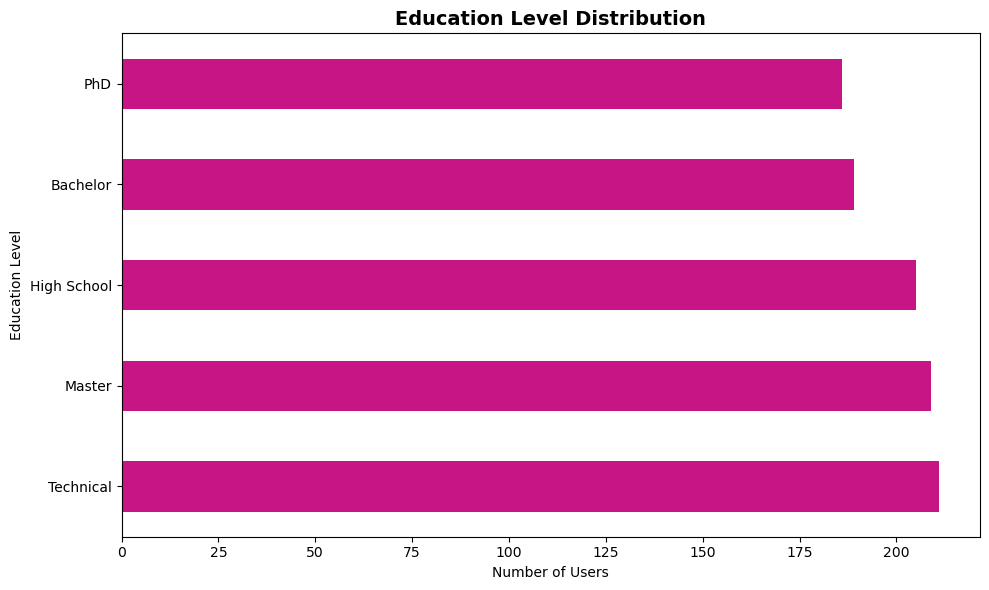

In [18]:
# Education Level Distribution
plt.figure(figsize=(10, 6))
df['Education Level'].value_counts().plot(kind='barh', color='#C71585')
plt.title('Education Level Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Users')
plt.tight_layout()
plt.show()

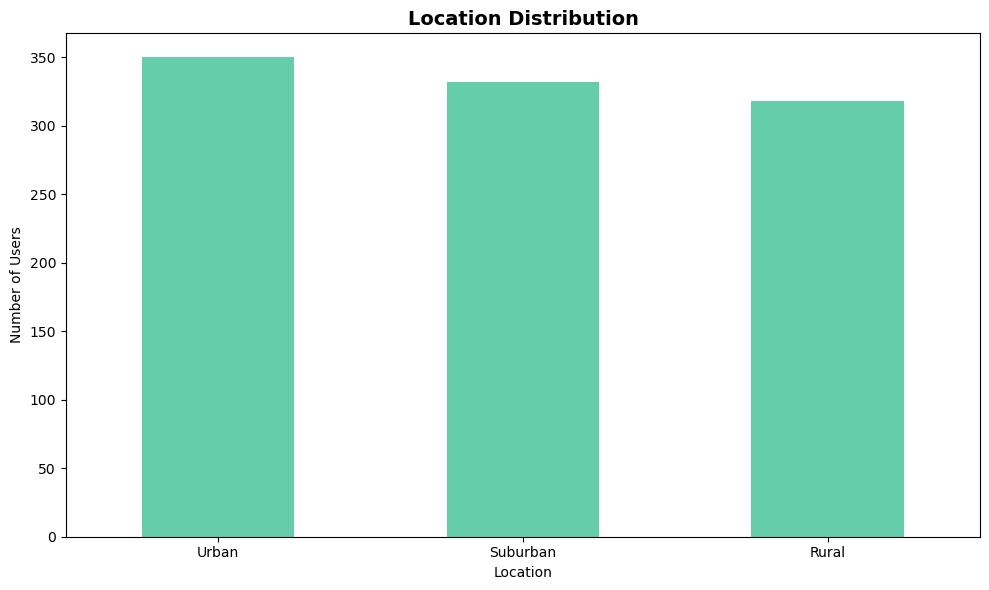

In [36]:
# Location Distribution
plt.figure(figsize=(10, 6))
df['Location'].value_counts().plot(kind='bar', color='#66CDAA')
plt.title('Location Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Location')
plt.ylabel('Number of Users')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

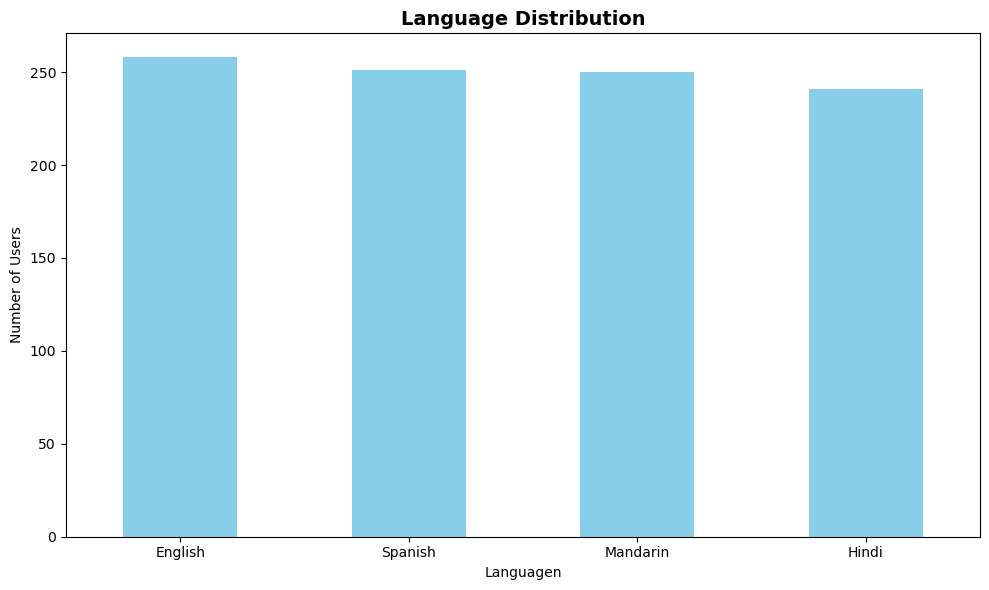

In [43]:
# Language Distribution
plt.figure(figsize=(10, 6))
df['Language'].value_counts().plot(kind='bar', color='#87CEEB')
plt.title('Language Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Languagen')
plt.ylabel('Number of Users')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

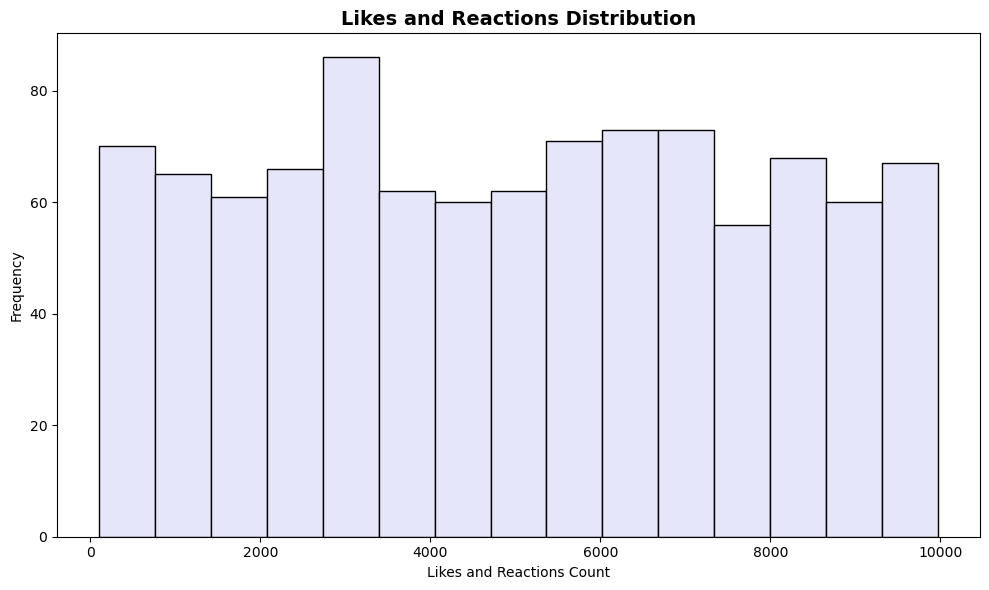

In [35]:
# Likes and Reactions Distribution
plt.figure(figsize=(10, 6))
plt.hist(df['Likes and Reactions'], bins=15, color='#E6E6FA', edgecolor='black')
plt.title('Likes and Reactions Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Likes and Reactions Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

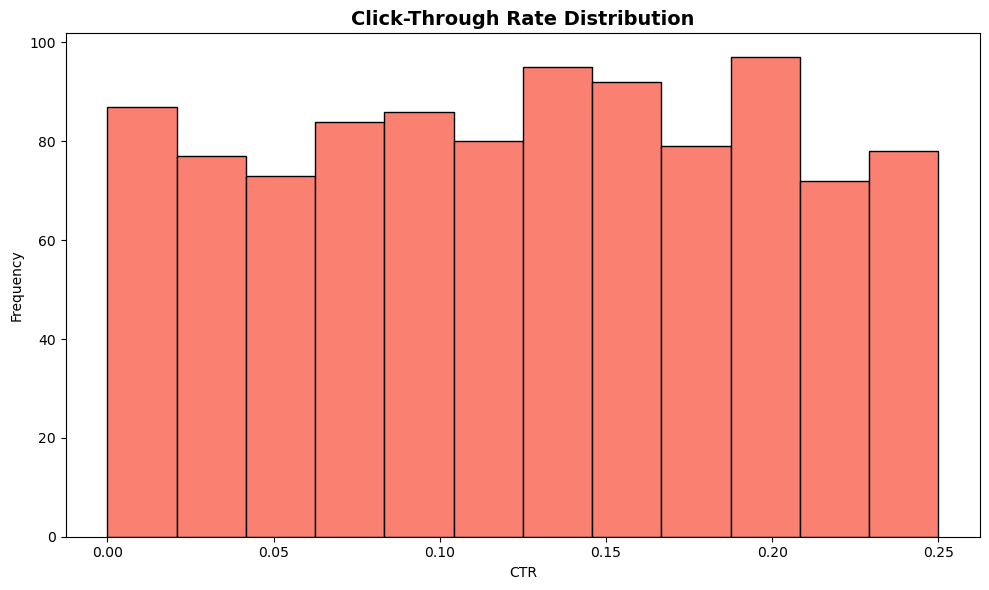

In [30]:
#Click-Through Rate (CTR) Distribution
plt.figure(figsize=(10, 6))
plt.hist(df['Click-Through Rates (CTR)'], bins=12, color='#FA8072', edgecolor='black')
plt.title('Click-Through Rate Distribution', fontsize=14, fontweight='bold')
plt.xlabel('CTR')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

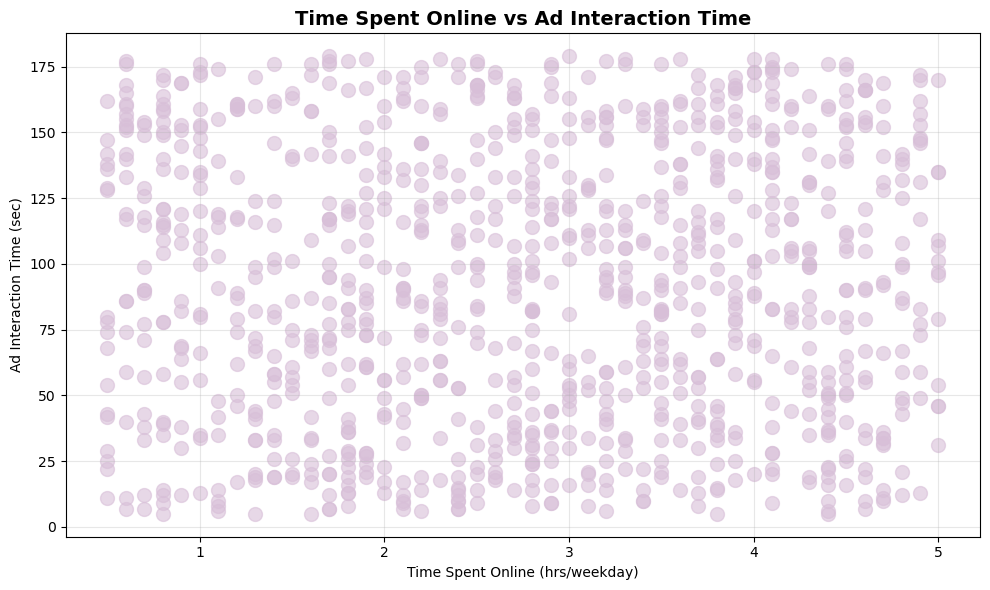

In [32]:
# 11. Time Spent Online vs Ad Interaction Time
plt.figure(figsize=(10, 6))
plt.scatter(df['Time Spent Online (hrs/weekday)'], df['Ad Interaction Time (sec)'], alpha=0.6, color='#D8BFD8', s=100)
plt.title('Time Spent Online vs Ad Interaction Time', fontsize=14, fontweight='bold')
plt.xlabel('Time Spent Online (hrs/weekday)')
plt.ylabel('Ad Interaction Time (sec)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   User ID                          1000 non-null   int64  
 1   Age                              1000 non-null   object 
 2   Gender                           1000 non-null   object 
 3   Location                         1000 non-null   object 
 4   Language                         1000 non-null   object 
 5   Education Level                  1000 non-null   object 
 6   Likes and Reactions              1000 non-null   int64  
 7   Followed Accounts                1000 non-null   int64  
 8   Device Usage                     1000 non-null   object 
 9   Time Spent Online (hrs/weekday)  1000 non-null   float64
 10  Time Spent Online (hrs/weekend)  1000 non-null   float64
 11  Click-Through Rates (CTR)        1000 non-null   float64
 12  Conversion Rates     

In [68]:
df.Age.value_counts()

Age
25-34    255
35-44    192
45-54    188
18-24    166
55-64    153
65+       46
Name: count, dtype: int64

In [69]:
age_level = {'18-24':0, '25-34':1, '35-44':2, '45-54':3, '55-64':4, '65+':5}
df['Age'] = df['Age'].map(age_level)

In [39]:
df.Gender.value_counts()

Gender
Female    506
Male      494
Name: count, dtype: int64

In [40]:
# Female -> 0, Male -> 1
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

In [41]:
df.Location.value_counts()

Location
Urban       350
Suburban    332
Rural       318
Name: count, dtype: int64

In [45]:
df['Education Level'].value_counts()

Education Level
Technical      211
Master         209
High School    205
Bachelor       189
PhD            186
Name: count, dtype: int64

In [48]:
df['Likes and Reactions'].describe()

count    1000.000000
mean     4997.084000
std      2838.494365
min       101.000000
25%      2661.250000
50%      5002.500000
75%      7348.750000
max      9973.000000
Name: Likes and Reactions, dtype: float64

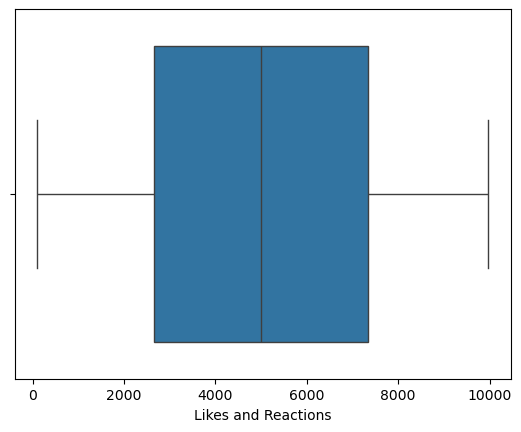

In [47]:
sns.boxplot(x=df['Likes and Reactions']);

In [50]:
df['Followed Accounts'].describe()

count    1000.000000
mean      251.438000
std       141.941557
min        10.000000
25%       126.000000
50%       245.500000
75%       377.000000
max       498.000000
Name: Followed Accounts, dtype: float64

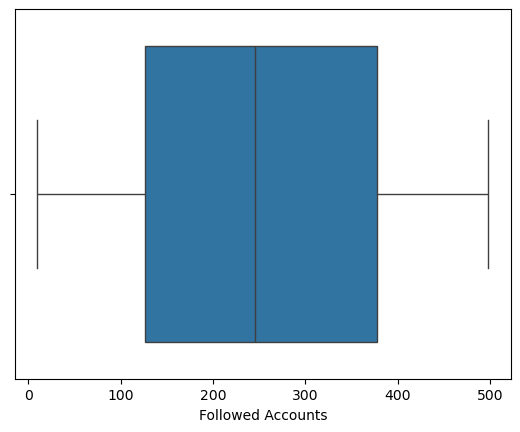

In [51]:
sns.boxplot(x=df['Followed Accounts']);

In [52]:
df['Device Usage'].value_counts()

Device Usage
Desktop Only        262
Mobile Only         253
Mobile + Desktop    250
Tablet              235
Name: count, dtype: int64

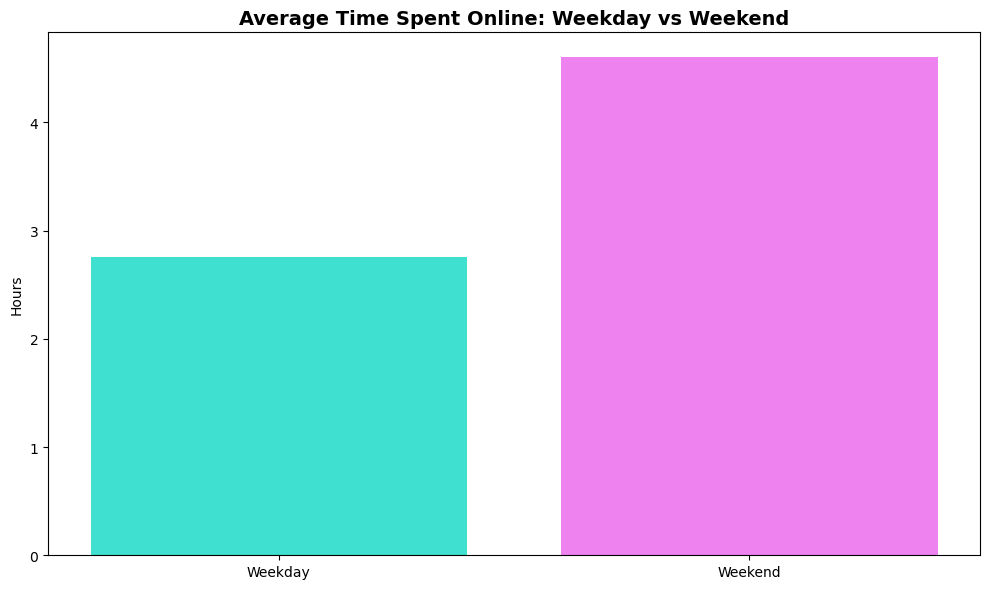

In [66]:
#Weekday vs Weekend Online Time Comparison
plt.figure(figsize=(10, 6))
weekday_avg = df['Time Spent Online (hrs/weekday)'].mean()
weekend_avg = df['Time Spent Online (hrs/weekend)'].mean()
plt.bar(['Weekday', 'Weekend'], [weekday_avg, weekend_avg], color=['#40E0D0', '#EE82EE'])
plt.title('Average Time Spent Online: Weekday vs Weekend', fontsize=14, fontweight='bold')
plt.ylabel('Hours')
plt.tight_layout()
plt.show()

In [55]:
df['Click-Through Rates (CTR)'].describe()

count    1000.000000
mean        0.125333
std         0.071187
min         0.000000
25%         0.065000
50%         0.128000
75%         0.186000
max         0.250000
Name: Click-Through Rates (CTR), dtype: float64

In [60]:
df['Conversion Rates'].describe()

count    1000.000000
mean        0.049805
std         0.028670
min         0.000000
25%         0.026000
50%         0.049000
75%         0.073000
max         0.100000
Name: Conversion Rates, dtype: float64

In [61]:
df['Income Level'].value_counts()

Income Level
100k+       176
40k-60k     175
60k-80k     168
80k-100k    168
20k-40k     165
0-20k       148
Name: count, dtype: int64

In [62]:
income_level = {
    '0-20k': 0,
    '20k-40k': 1,
    '40k-60k': 2,
    '60k-80k': 3,
    '80k-100k': 4,
    '100k+': 5
}
df['Income Level'] = df['Income Level'].map(income_level)

In [63]:
df['Top Interests'].value_counts()

Top Interests
Investing and Finance                                                       23
Pet Care                                                                    18
Gaming                                                                      18
Reading and Literature                                                      17
Digital Marketing                                                           17
                                                                            ..
DIY Crafts, Fitness and Wellness, Software Engineering, Gourmet Cooking      1
DIY Crafts, Fashion Modelling, Eco-Friendly Living, Software Engineering     1
Fashion Modelling, Photography, Digital Marketing                            1
Software Engineering, Eco-Friendly Living, Gardening, Photography            1
Software Engineering, DIY Crafts                                             1
Name: count, Length: 680, dtype: int64

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   User ID                          1000 non-null   int64  
 1   Age                              1000 non-null   int64  
 2   Gender                           1000 non-null   int64  
 3   Location                         1000 non-null   object 
 4   Language                         1000 non-null   object 
 5   Education Level                  1000 non-null   object 
 6   Likes and Reactions              1000 non-null   int64  
 7   Followed Accounts                1000 non-null   int64  
 8   Device Usage                     1000 non-null   object 
 9   Time Spent Online (hrs/weekday)  1000 non-null   float64
 10  Time Spent Online (hrs/weekend)  1000 non-null   float64
 11  Click-Through Rates (CTR)        1000 non-null   float64
 12  Conversion Rates     

In [71]:
# Remove User ID column
df = df.drop('User ID', axis=1)

In [74]:
# ENcoding categorical features
le_dict = {}
categorical_cols = ['Gender', 'Location', 'Language', 'Education Level', 'Device Usage', 'Income Level']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

In [77]:
# One-Hot Encoding Top Interests
interests_split = [item.split(', ') for item in df['Top Interests']]
mlb = MultiLabelBinarizer()
interests_encoded = mlb.fit_transform(interests_split)
interests_df = pd.DataFrame(
    interests_encoded, 
    columns=['Interest_' + str(col) for col in mlb.classes_]
)

interests_df['Interest_Count'] = df['Top Interests'].apply(lambda x: len(x.split(', ')))

In [78]:
interests_df.head()

,Interest_DIY Crafts,Interest_Data Science,Interest_Digital Marketing,Interest_Eco-Friendly Living,Interest_Fashion Modelling,Interest_Fitness and Wellness,Interest_Gaming,Interest_Gardening,Interest_Gourmet Cooking,Interest_Investing and Finance,Interest_Music Production,Interest_Pet Care,Interest_Photography,Interest_Reading and Literature,Interest_Software Engineering,Interest_Travel and Adventure,Interest_Count
0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2
4,0,0,0,0,0,1,0,1,0,1,1,0,0,0,0,0,4


In [96]:
x = df.drop('Top Interests', axis=1)

In [97]:
x = pd.concat([df, interests_df], axis=1)

In [98]:
x.head()

,Age,Gender,Location,Language,Education Level,Likes and Reactions,Followed Accounts,Device Usage,Time Spent Online (hrs/weekday),Time Spent Online (hrs/weekend),...,Interest_Gardening,Interest_Gourmet Cooking,Interest_Investing and Finance,Interest_Music Production,Interest_Pet Care,Interest_Photography,Interest_Reading and Literature,Interest_Software Engineering,Interest_Travel and Adventure,Interest_Count
0,1,0,1,1,4,5640,190,2,4.5,1.7,...,0,0,0,0,0,0,0,0,0,1
1,5,1,2,1,3,9501,375,3,0.5,7.7,...,0,0,0,0,0,0,0,0,0,1
2,3,0,1,3,4,4775,187,2,4.5,5.6,...,0,0,0,0,0,0,0,0,0,1
3,2,0,0,3,3,9182,152,0,3.1,4.2,...,0,0,0,0,0,0,0,0,0,2
4,1,0,2,0,4,6848,371,2,2.0,3.8,...,1,0,1,1,0,0,0,0,0,4


In [99]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              1000 non-null   int64  
 1   Gender                           1000 non-null   int64  
 2   Location                         1000 non-null   int64  
 3   Language                         1000 non-null   int64  
 4   Education Level                  1000 non-null   int64  
 5   Likes and Reactions              1000 non-null   int64  
 6   Followed Accounts                1000 non-null   int64  
 7   Device Usage                     1000 non-null   int64  
 8   Time Spent Online (hrs/weekday)  1000 non-null   float64
 9   Time Spent Online (hrs/weekend)  1000 non-null   float64
 10  Click-Through Rates (CTR)        1000 non-null   float64
 11  Conversion Rates                 1000 non-null   float64
 12  Ad Interaction Time (

In [102]:
model=KMeans(4)      #Burada 4 gruba ayırıyoruz

In [103]:
model=model.fit(x)

In [104]:
tahmin=model.predict(x)

In [105]:
x['Cluster']=tahmin

In [106]:
x.head()

,Age,Gender,Location,Language,Education Level,Likes and Reactions,Followed Accounts,Device Usage,Time Spent Online (hrs/weekday),Time Spent Online (hrs/weekend),...,Interest_Gourmet Cooking,Interest_Investing and Finance,Interest_Music Production,Interest_Pet Care,Interest_Photography,Interest_Reading and Literature,Interest_Software Engineering,Interest_Travel and Adventure,Interest_Count,Cluster
0,1,0,1,1,4,5640,190,2,4.5,1.7,...,0,0,0,0,0,0,0,0,1,2
1,5,1,2,1,3,9501,375,3,0.5,7.7,...,0,0,0,0,0,0,0,0,1,1
2,3,0,1,3,4,4775,187,2,4.5,5.6,...,0,0,0,0,0,0,0,0,1,3
3,2,0,0,3,3,9182,152,0,3.1,4.2,...,0,0,0,0,0,0,0,0,2,1
4,1,0,2,0,4,6848,371,2,2.0,3.8,...,0,1,1,0,0,0,0,0,4,2


<Axes: xlabel='Cluster', ylabel='count'>

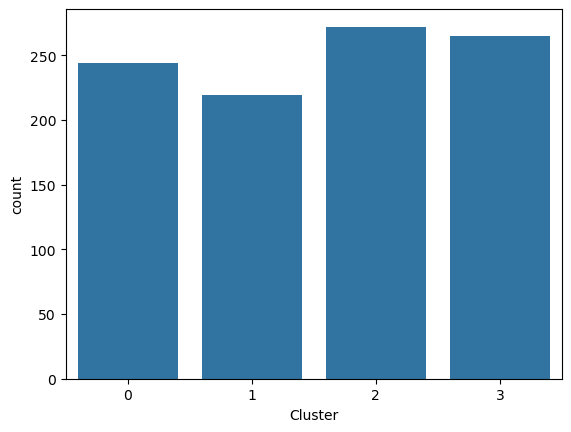

In [107]:
sns.countplot(x=x['Cluster'])

In [124]:
x.Cluster.value_counts()

Cluster
2    272
3    265
0    244
1    219
Name: count, dtype: int64

In [108]:
silhouette_score(x,tahmin)

0.5596631342311422

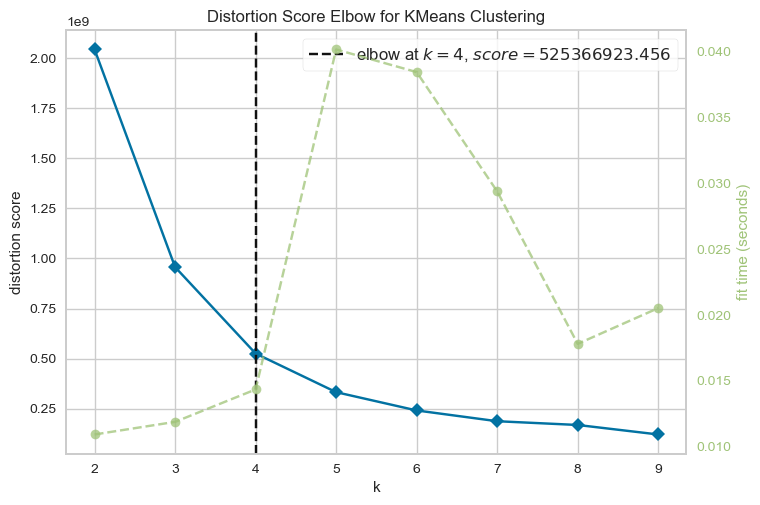

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [110]:
vis=KElbowVisualizer(KMeans(), k=(2,10))           #zaten datayı gruplara ayıracağımız için 1e bölmek demek datanın kendisine bölmek oluyor
vis.fit(x)
vis.show()

In [111]:
#wcss= within cluster sum of squares uzaklıkları hesaplayarak türev alarak en optimum uzaklığı buluyor yer seçimi için inceleyebiliriz
wcss=[]
ss=[]
for i in range(2,10):
    model=KMeans(i)
    model=model.fit(x)
    tahmin=model.predict(x)
    ss1=silhouette_score(x,tahmin)
    ss.append(ss1)
    print(ss1)
    wcss.append(model.inertia_)

0.6216193884479589
0.5703061657557799
0.5596631342311422
0.5512150922893916
0.5339891808223488
0.5225362374265364
0.5130153182734533
0.48075855156597325


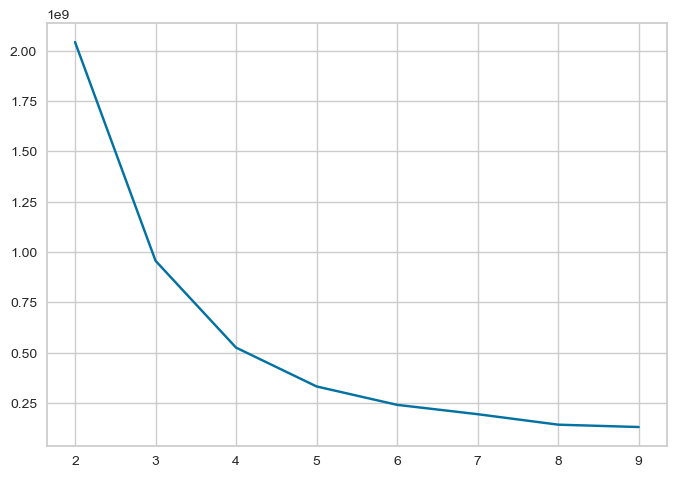

In [112]:
plt.plot(range(2,10), wcss)   #dirsek nerede kırılırsa optimum grup o kadardır.

In [113]:
## Hierarchical Clustering 

In [114]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [115]:
data=linkage(x,method='ward',metric='euclidean')

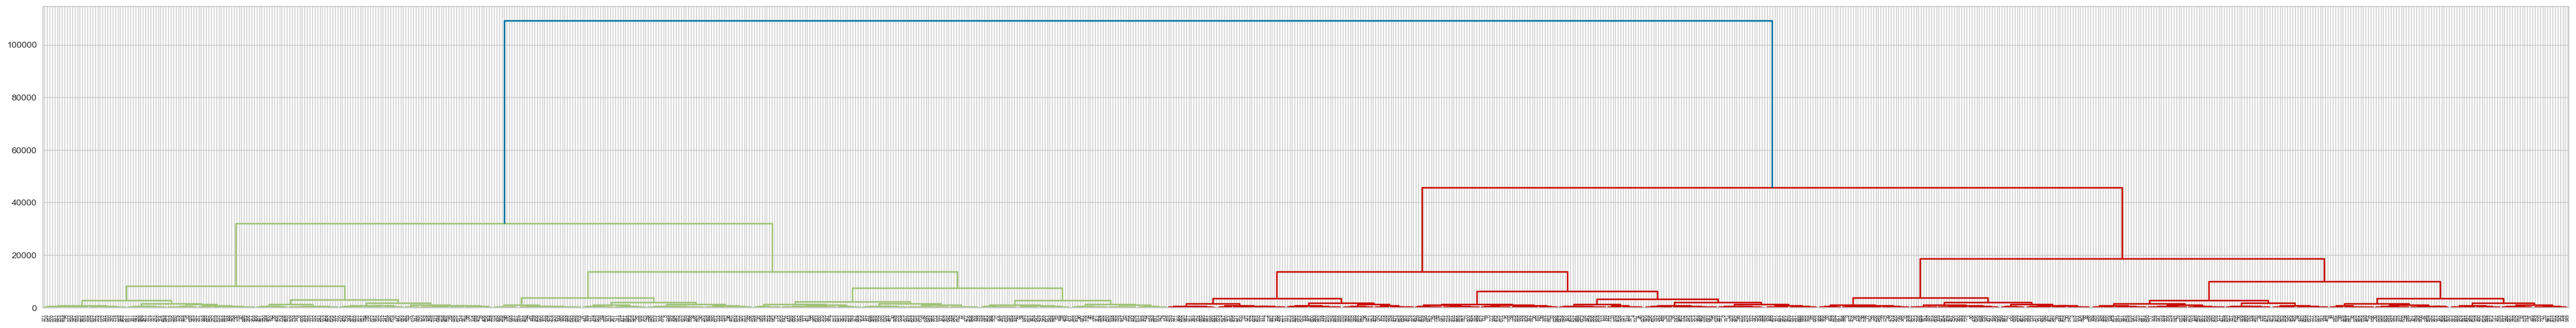

In [116]:
plt.figure(figsize=(50,6))
dendrogram(data);

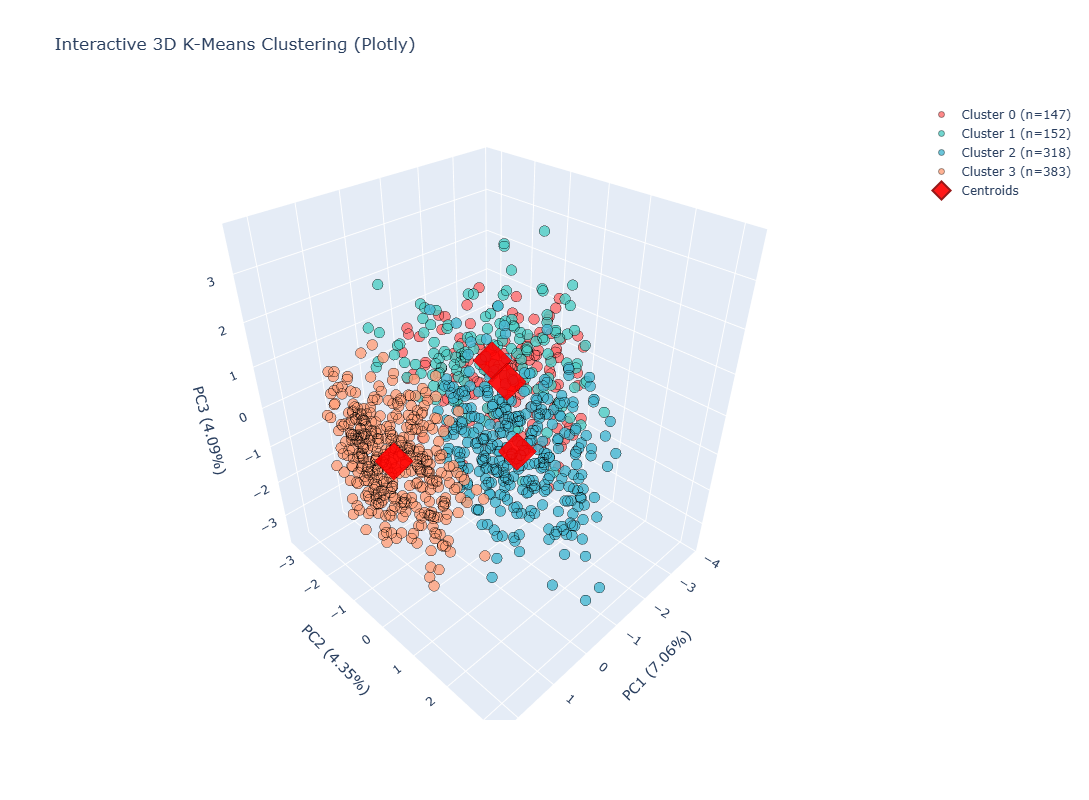

In [139]:
# ============================================================
# PLOTLY METHOS - 3D PLOTTING 
# ============================================================
# Normalizaiton
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

# K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)  

# DataFrame
x['Cluster'] = clusters

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

fig_plotly = go.Figure()

for cluster_id in sorted(np.unique(clusters)):
    cluster_mask = clusters == cluster_id
    
    fig_plotly.add_trace(go.Scatter3d(
        x=X_pca[cluster_mask, 0],
        y=X_pca[cluster_mask, 1],
        z=X_pca[cluster_mask, 2],
        mode='markers',
        name=f'Cluster {cluster_id} (n={cluster_counts[cluster_id]})',
        marker=dict(
            size=6,
            color=colors[cluster_id],
            opacity=0.8,
            line=dict(width=0.5, color='black')
        ),
        hovertemplate='<b>Cluster %{fullData.name}</b><br>PC1: %{x:.2f}<br>PC2: %{y:.2f}<br>PC3: %{z:.2f}<extra></extra>'
    ))

# Centroids - ✅ DÜZELTILDI: 'star' yerine 'diamond' kullanıyoruz
fig_plotly.add_trace(go.Scatter3d(
    x=centroids_pca[:, 0],
    y=centroids_pca[:, 1],
    z=centroids_pca[:, 2],
    mode='markers',
    name='Centroids',
    marker=dict(
        size=14,
        color='red',
        symbol='diamond',  # ✅ Geçerli symbol: circle, diamond, cross, x, square, etc.
        line=dict(width=2, color='darkred'),
        opacity=0.9
    ),
    hovertemplate='<b>Centroid</b><br>PC1: %{x:.2f}<br>PC2: %{y:.2f}<br>PC3: %{z:.2f}<extra></extra>'
))

fig_plotly.update_layout(
    title='Interactive 3D K-Means Clustering (Plotly)',
    scene=dict(
        xaxis_title=f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)',
        yaxis_title=f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)',
        zaxis_title=f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)',
    ),
    width=1000,
    height=800,
    hovermode='closest',
    font=dict(size=12)
)

fig_plotly.show()

As a result of the clustering analysis, the dataset was divided into four distinct user segments. These clusters form meaningful groups based on users' behavioral and demographic characteristics, enabling the development of tailored strategies for each segment.